In [1]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv("../data/youtoxic_english_1000.csv")

# Dimensiones: filas y columnas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Primeras filas para ver la pinta general
df.head()

Filas: 1000, Columnas: 15


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [2]:
# Eliminar duplicados exactos por texto
df = df.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 997


In [3]:
import matplotlib.pyplot as plt

IsToxic
False    538
True     459
Name: count, dtype: int64
IsToxic
False    53.961886
True     46.038114
Name: proportion, dtype: float64


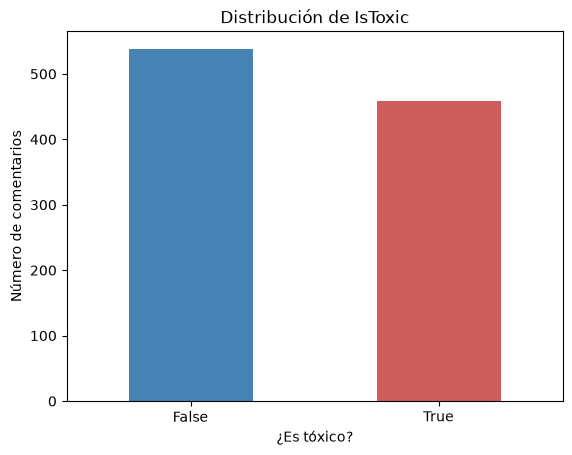

In [4]:
print(df['IsToxic'].value_counts())
print(df['IsToxic'].value_counts(normalize=True) * 100)

df['IsToxic'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Distribución de IsToxic')
plt.xlabel('¿Es tóxico?')
plt.ylabel('Número de comentarios')
plt.xticks(rotation=0)
plt.show()

       longitud_caracteres  longitud_palabras
count           997.000000         997.000000
mean            186.073220          33.868606
std             271.022372          49.114220
min               3.000000           1.000000
25%              47.000000           9.000000
50%             102.000000          19.000000
75%             217.000000          39.000000
max            4421.000000         815.000000


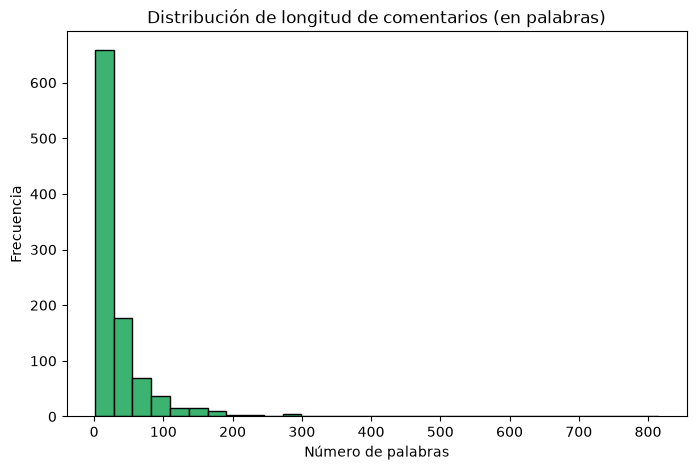

In [5]:
df['longitud_caracteres'] = df['Text'].str.len()
df['longitud_palabras'] = df['Text'].str.split().str.len()

print(df[['longitud_caracteres', 'longitud_palabras']].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['longitud_palabras'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribución de longitud de comentarios (en palabras)')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

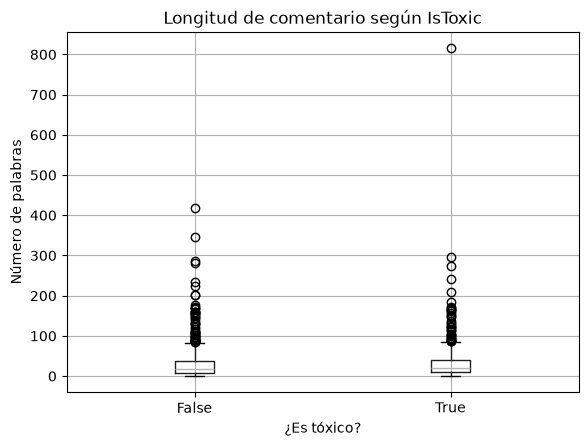

In [6]:
df.boxplot(column='longitud_palabras', by='IsToxic')
plt.title('Longitud de comentario según IsToxic')
plt.suptitle('')
plt.xlabel('¿Es tóxico?')
plt.ylabel('Número de palabras')
plt.show()

In [7]:
from collections import Counter

In [8]:
palabras_toxic = ' '.join(df[df['IsToxic'] == True]['Text']).lower().split()
palabras_no_toxic = ' '.join(df[df['IsToxic'] == False]['Text']).lower().split()

print("Top 15 palabras en comentarios TÓXICOS:")
print(Counter(palabras_toxic).most_common(15))

print("\nTop 15 palabras en comentarios NO tóxicos:")
print(Counter(palabras_no_toxic).most_common(15))

Top 15 palabras en comentarios TÓXICOS:
[('the', 704), ('a', 393), ('and', 369), ('to', 365), ('of', 271), ('is', 228), ('you', 202), ('in', 189), ('that', 181), ('this', 172), ('i', 167), ('they', 138), ('are', 134), ('was', 123), ('black', 113)]

Top 15 palabras en comentarios NO tóxicos:
[('the', 837), ('to', 444), ('and', 438), ('a', 391), ('of', 328), ('is', 302), ('that', 262), ('in', 242), ('i', 232), ('you', 222), ('this', 192), ('are', 178), ('for', 143), ('it', 141), ('not', 138)]


## Conclusiones del EDA

- Dataset: 997 filas tras eliminar 3 duplicados exactos por texto (de 1000 originales).
- Sin valores nulos ni comentarios vacíos.
- Variable objetivo `IsToxic`: 46.0% positivos (459/997) → dataset razonablemente
  balanceado. Aun así se usará class_weight='balanced' en los modelos y se vigilarán
  precision/recall/F1 en ambas clases (no solo accuracy).
- Longitud de comentarios muy sesgada a la derecha (mediana 19 palabras, máximo 815).
- Los duplicados detectados diferían solo en mayúsculas/minúsculas → confirma la
  necesidad de normalizar el texto a minúsculas antes de vectorizar.
- Las palabras más frecuentes en ambas clases son mayoritariamente stopwords. La única
  excepción es "black", que aparece en el top 15 de comentarios tóxicos (113 veces) pero
  no en el de no tóxicos → señal de que el tema racial está sobrerrepresentado en los
  comentarios marcados como tóxicos de este dataset, algo a mencionar como limitación/sesgo
  del dataset en las conclusiones finales del proyecto.